# 02 – Análisis del mapa *tent*

En este notebook se estudian las propiedades dinámicas del mapa *tent*, un sistema dinámico unidimensional muy utilizado como ejemplo de comportamiento caótico.

El mapa *tent* viene dado por la ecuación

$$
x_{n+1} =
\begin{cases}
a\,x_n, & 0 \le x_n < \tfrac12,\\\\
a\,(1 - x_n), & \tfrac12 \le x_n \le 1,
\end{cases}
\qquad 0 < a \le 2.
$$

En este documento se trabajará principalmente con valores cercanos a $a = 2$, donde el mapa presenta un comportamiento fuertemente caótico y, en el caso ideal continuo, la órbita visita el intervalo $(0,1)$ de forma casi uniforme.

En este notebook se estudiarán:

1. La evolución temporal de $x_n$ (serie temporal) para parámetros clásicos.
2. El atractor numérico del mapa *tent*.
3. Un diagrama tipo "bifurcación" al variar el parámetro $a$.
4. El exponente de Lyapunov máximo $\lambda(a)$.
5. El efecto del número de iteraciones transitorias al aproximar propiedades estadísticas.
6. El efecto del umbral de binarización al generar bits a partir de $x_n$.
7. Las limitaciones numéricas debidas a la aritmética en coma flotante y su impacto en el espacio efectivo de claves.
8. Una breve conclusión con las ideas principales del análisis.

Además, se incluyen dos apéndices:

- **Apéndice A** – Sensibilidad del mapa *tent* frente a pequeñas variaciones del parámetro $a$.
- **Apéndice B** – Comportamiento especial del caso límite $a = 2$ y sus implicaciones numéricas.


## 0. Preparación del entorno

En esta sección se configura el entorno de trabajo y se importan las funciones necesarias para el análisis del mapa *tent*.

En particular:

- Se añade la carpeta raíz del proyecto a `sys.path` para poder importar los módulos de `analysis` y `utils`.
- Se importan las funciones auxiliares específicas del mapa *tent* desde `analysis.tent_analysis`.
- Además, se cargan utilidades numéricas genéricas desde `utils.numerics_utils`, independientes del mapa concreto.

### Funciones del módulo `analysis.tent_analysis`

- `plot_orbit_tent(...)` – dibuja la serie temporal de $x_n$ para un valor dado de $a$.
- `plot_attractor_tent(...)` – visualiza el atractor numérico en el intervalo $(0,1)$.
- `plot_bifurcation_tent(...)` – genera un diagrama tipo bifurcación al variar el parámetro $a$.
- `plot_lyapunov_vs_a_tent(...)` – calcula y representa el exponente de Lyapunov máximo $\lambda_1(a)$.
- `explore_transient_effect_tent(...)` – estudia el efecto del número de iteraciones transitorias.
- `plot_threshold_effect_tent(...)` – analiza el efecto del umbral de binarización sobre la proporción de unos.
- `detect_cycle_tent(...)` – busca de forma aproximada ciclos periódicos en una órbita larga.
- `plot_divergence_two_orbits_tent(...)` – representa gráficamente la divergencia de dos órbitas próximas (normalmente en escala semilogarítmica).
- **Funciones para los apéndices:**
  - `plot_param_sensitivity_tent(...)` – analiza la sensibilidad del sistema frente a pequeñas variaciones del parámetro $a$.
  - `plot_orbit_a_equals_2_tent(...)` – ilustra el comportamiento especial del caso $a = 2$.

### Utilidades numéricas (`utils.numerics_utils`)

- `float_spacing_around_05(...)` – estima la separación entre números de doble precisión alrededor de $x = 0.5$.

En las secciones siguientes utilizaremos estas funciones para explorar cuantitativamente el comportamiento del mapa *tent* y estimar el tamaño efectivo del espacio de claves cuando se emplean parámetros y condiciones iniciales en doble precisión.


In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Añadimos la carpeta raíz del proyecto (una arriba de notebooks)
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Importamos las funciones específicas del mapa tent
from analysis.tent_analysis import (
    plot_orbit_tent,
    plot_attractor_tent,
    plot_bifurcation_tent,
    plot_lyapunov_vs_a_tent,
    explore_transient_effect_tent,
    plot_threshold_effect_tent,
    detect_cycle_tent,
    plot_divergence_two_orbits_tent,
    # Funciones añadidas para los apéndices
    plot_param_sensitivity_tent,
    plot_orbit_a_equals_2_tent,
)

# Utilidades numéricas genéricas
from utils.numerics_utils import (
    float_spacing_around_05,
    interval_capacity,
    bits_from_interval,
)


## 1. Órbita y serie temporal para parámetros clásicos

Para fijar ideas, comenzamos estudiando la evolución temporal de una órbita del mapa *tent* para un valor de parámetro caótico y una condición inicial dada.

En esta sección:

- Fijaremos un valor de $a$ en la región caótica (por ejemplo, $a = 1.999$).
- Elegiremos una condición inicial $x_0$ en $(0,1)$.
- Representaremos la serie temporal $x_n$ en función de $n$.

Esto proporciona una primera visión cualitativa del comportamiento del sistema.


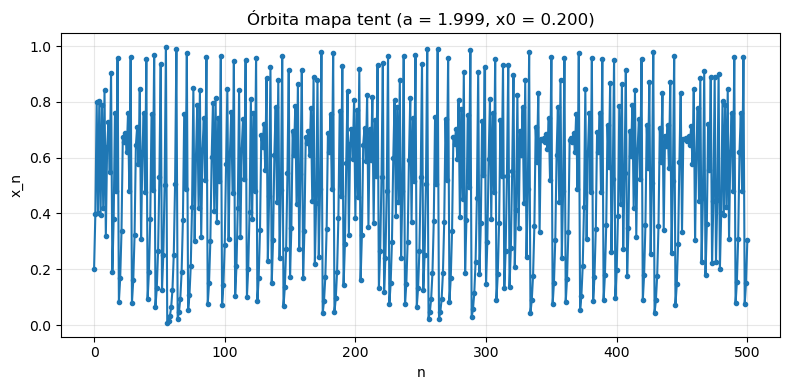

In [16]:
# Parámetros "clásicos" del mapa tent
a_chaotico = 1.999    # en vez de 2.0 para evitar colapsos numéricos
x0 = 0.2

plot_orbit_tent(
    x0=x0,
    a=a_chaotico,
    n_iters=500,
)


### Interpretación de la serie temporal en el mapa *tent*

La figura anterior muestra la evolución temporal de $x_n$ para el mapa *tent* con parámetro $a = 1.999$ y condición inicial $x_0 = 0.2$.

Se observa que:

- La señal **no converge** a un punto fijo ni a un ciclo de periodo corto: los valores de $x_n$ oscilan a lo largo de todo el intervalo $(0,1)$.
- El comportamiento es **aparentemente irregular**, sin patrones periódicos claros a simple vista, lo que es consistente con una dinámica caótica.
- Si se cambian ligeramente $x_0$ o $a$, la serie temporal resultante cambia de forma apreciable, reflejando una alta sensibilidad a las condiciones iniciales y a los parámetros.

Esta serie temporal proporciona una primera evidencia de que, para estos parámetros, el mapa *tent* se encuentra en un régimen caótico.


## 2. Atractor numérico del mapa *tent*

En la región caótica, la órbita del mapa *tent* no converge a un conjunto finito de puntos, sino que "vive" sobre un atractor dentro del intervalo $(0,1)$.

Para aproximar este atractor de forma numérica:

1. Se fija un valor de $a$ en la región caótica (por ejemplo, $a = 1.999$).
2. Se descartan varias iteraciones transitorias (por ejemplo, $n_{\text{transient}} = 1000$).
3. A continuación se representan únicamente los últimos $n_{\text{points}}$ valores de la órbita.

La figura siguiente muestra los puntos $x_n$ en función del índice $n$ tras descartar el transitorio; en este caso es básicamente una "nube" en $(0,1)$.


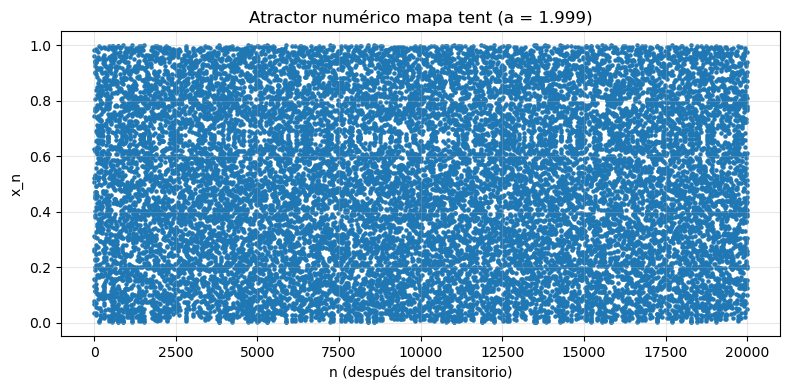

In [17]:
# 2. Atractor numérico para un valor caótico de a

# Parámetros "clásicos" del mapa tent
a_caotico = 1.999   # usamos un valor cercano a 2.0 para evitar saturación numérica
x0 = 0.2

plot_attractor_tent(
    a=a_caotico,
    x0=x0,
    n_transient=1_000,
    n_points=20_000,
)


### Interpretación del "atractor numérico" en el mapa *tent*

La figura muestra los últimos valores de la órbita tras descartar un transitorio largo.

Se observa que:

- Los valores de $x_n$ exploran buena parte del intervalo $(0,1)$.
- No aparecen bandas vacías pronunciadas ni acumulaciones claras en pocos niveles discretos, lo que es coherente con una distribución relativamente uniforme para $a = 1.999$ en el caso ideal continuo.
- La nube de puntos da una idea de la región del espacio de estados donde la órbita pasa la mayor parte del tiempo.

Este tipo de atractor será el que se utilice como base para el generador de bits asociado al mapa *tent*.


## 3. Diagrama de bifurcación en función del parámetro $a$

El diagrama de bifurcación del mapa *tent* representa, para cada valor del parámetro $a$, los valores posibles de $x_n$ en régimen estacionario (es decir, después de descartar el transitorio).

Procedimiento numérico:

1. Se recorre un intervalo de valores de $a$ (por ejemplo, de $0.5$ a $2.0$).
2. Para cada $a$:
   - se simula la órbita desde una condición inicial $x_0$,
   - se descartan $n_{\text{transient}}$ iteraciones,
   - se representan los siguientes $n_{\text{plot}}$ valores de $x_n$.

En el diagrama resultante se observa:

- La aparición de regiones de comportamiento periódico para ciertos valores de $a$.
- La transición a la región caótica, donde los puntos llenan densamente el intervalo.
- La correspondencia entre zonas de caos y zonas donde el exponente de Lyapunov es positivo.


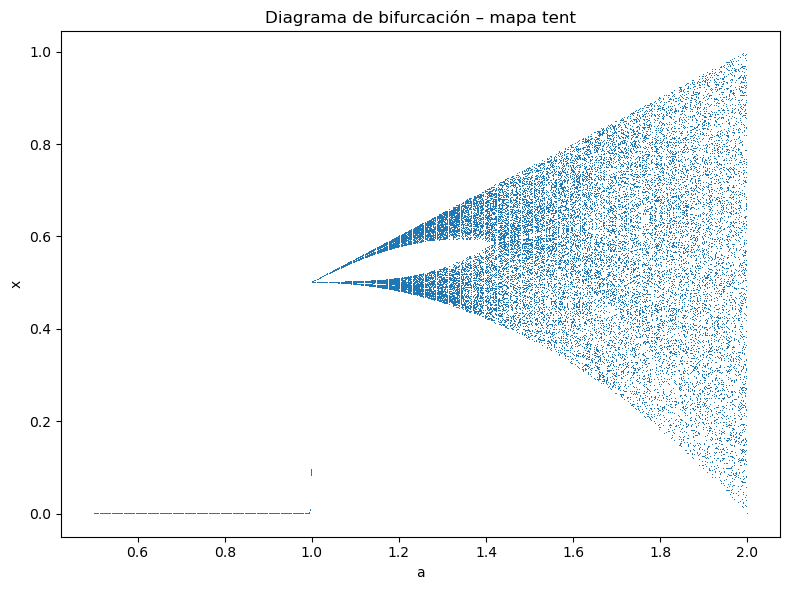

In [18]:
plot_bifurcation_tent(
    a_min=0.5,
    a_max=2.0,
    a_points=600,
    x0=0.5,
    n_transient=1_000,
    n_plot=80,
)


### Interpretación del diagrama de bifurcación

En el diagrama se aprecia cómo cambia el comportamiento del mapa *tent* al variar el parámetro $a$:

- Para valores pequeños de $a$ la órbita converge a puntos fijos o ciclos de periodo finito.
- A medida que aumenta $a$ aparecen **bifurcaciones de periodo** que duplican el periodo de los ciclos.
- Para valores de $a$ próximos a $2$ la dinámica se vuelve caótica y los puntos de la órbita llenan densamente el intervalo $(0,1)$.

Este diagrama resume de forma gráfica los distintos regímenes dinámicos del mapa *tent* en función del parámetro de control.


## 4. Exponente de Lyapunov máximo $\lambda(a)$

El exponente de Lyapunov máximo mide el ritmo medio al que divergen dos órbitas con condiciones iniciales muy próximas. Para el mapa *tent*:

- Si $\lambda(a) < 0$, las órbitas tienden a acercarse y el comportamiento es estable (puntos fijos o ciclos).
- Si $\lambda(a) > 0$, las órbitas divergen exponencialmente y el sistema es caótico (sensibilidad a las condiciones iniciales).

En esta sección calculamos numéricamente $\lambda(a)$ para un rango de valores de $a$ y lo representamos en función de dicho parámetro.


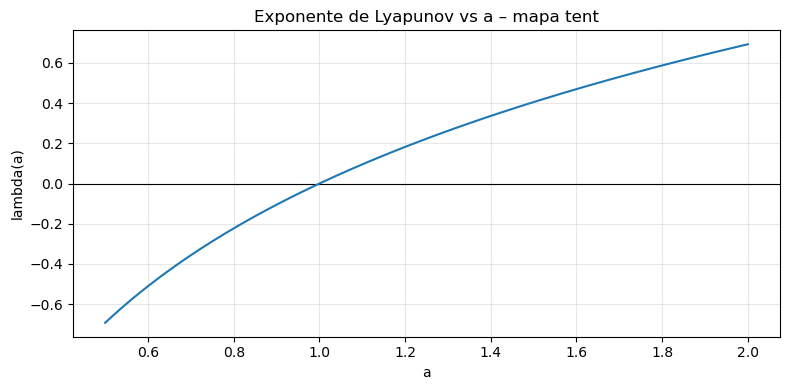

In [19]:
plot_lyapunov_vs_a_tent(
    a_min=0.5,
    a_max=2.0,
    a_points=300,
    x0=0.5,
    n_transient=1_000,
    n_iters=3_000,
)


### Interpretación del exponente de Lyapunov

La curva $\lambda(a)$ muestra:

- Regiones donde $\lambda(a) < 0$, que coinciden con zonas de órbitas periódicas en el diagrama de bifurcación.
- Regiones donde $\lambda(a) > 0$, que se corresponden con comportamiento caótico y sensibilidad a las condiciones iniciales.
- Para valores cercanos a $a = 2$ el exponente es claramente positivo, lo que justifica el uso de estos parámetros en el generador de bits.

Esta función complementa el diagrama de bifurcación y proporciona una medida cuantitativa del grado de caos para cada valor de $a$.


## 5. Justificación empírica del número de iteraciones transitorias

Al generar bitstreams caóticos se descartan varias miles de iteraciones transitorias antes de utilizar los valores del sistema. La intuición es que, tras un cierto tiempo, la órbita "olvida" la condición inicial y se aproxima al comportamiento en régimen.

Para justificar de forma empírica el orden de magnitud del transitorio, en esta sección se estudia cómo varía una estadística sencilla (la media de $x_n$) cuando se descartan distintos números de iteraciones $T$.


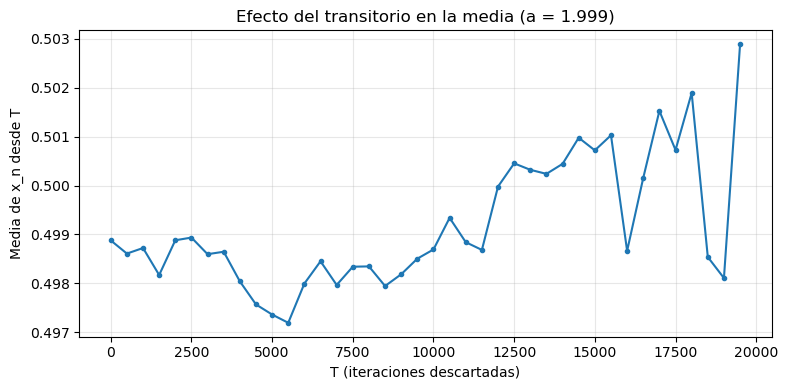

In [20]:
explore_transient_effect_tent(
    a=a_caotico,
    x0=x0,
    n_total=20_000,
    step=500,
)


### Interpretación del efecto del transitorio

La figura muestra cómo cambia la media de $x_n$ al descartar diferentes números de iteraciones transitorias $T$.

Se observa que:

- Para valores pequeños de $T$ la estadística todavía depende de la condición inicial y puede variar de forma apreciable.
- A partir de cierto orden de magnitud del transitorio (del orden de varios miles de iteraciones), las variaciones se reducen y la media se estabiliza alrededor de un valor casi constante.
- Si $T$ se hace demasiado grande respecto al número total de iteraciones, la estimación se vuelve más ruidosa porque se promedia sobre muy pocos puntos.

Este análisis orienta la elección de un valor de $n_{\text{transient}}$ del orden de varios miles también para el mapa *tent*, en línea con lo que se hace en el resto del proyecto.


## 6. Justificación empírica del umbral de binarización

En el generador de bits basado en el mapa *tent*, cada valor de la órbita se transforma en un bit mediante la regla

$$
\text{bit}_n =
\begin{cases}
1, & \text{si } x_n > \theta,\\\\
0, & \text{en otro caso},
\end{cases}
$$

donde $\theta \in (0,1)$ es el **umbral de binarización**.

En el caso ideal continuo con $a = 2$, la órbita del mapa *tent* tiene una distribución invariante uniforme en $(0,1)$. En ese caso, si $x_n$ es uniforme en $(0,1)$, la probabilidad teórica de obtener un uno es

$$
p(1) = \mathbb{P}(x_n > \theta) = 1 - \theta.
$$

En esta sección se estudia empíricamente cómo varía la proporción de unos $\hat p(1)$ al cambiar $\theta$, y se compara con el valor ideal $1 - \theta$.


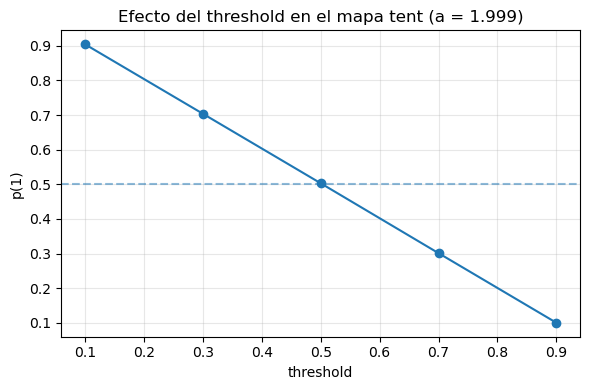

In [21]:
plot_threshold_effect_tent(
    a=1.999,
    x0=0.5,
    n_transient=5_000,
    n_points=1_000_000,
    thresholds=[0.1, 0.3, 0.5, 0.7, 0.9],
)


### Interpretación del efecto del umbral en el mapa *tent*

La gráfica de $p(1)$ frente a $\theta$ muestra:

- Una tendencia aproximadamente **decreciente y casi lineal**, en concordancia con la ley ideal $p(1) \approx 1 - \theta$.
- Pequeñas desviaciones debidas a la longitud finita de la órbita, al transitorio descartado y a las limitaciones numéricas de la aritmética en coma flotante.

Esto sugiere que, para $a = 2$, el mapa *tent* produce valores $x_n$ razonablemente bien distribuidos en $(0,1)$, lo que permite obtener secuencias binarias equilibradas para umbrales adecuados.


## 7. Limitaciones numéricas y precisión en coma flotante

En este notebook el mapa *tent* se implementa con aritmética de coma flotante en doble precisión (formato IEEE 754). Esto implica que:

- El espacio de estados es **finito** (solo hay un número discreto de valores de $x_n$ representables).
- La dinámica numérica es, en realidad, una aplicación determinista sobre un conjunto finito, por lo que **toda órbita acaba siendo periódica** tras un cierto preperíodo.
- El tamaño del espacio de claves (valores posibles del parámetro $a$ y de la condición inicial $x_0$) está acotado por la resolución de la aritmética en coma flotante.

En los siguientes apartados se estudian estas cuestiones de forma empírica y se discute cómo afectan al tamaño efectivo del *keyspace* asociado al mapa *tent*.


### 7.1 Tamaño del *keyspace* asociado a variables reales en doble precisión

Comenzamos estimando la resolución numérica alrededor de $x = 0.5$ usando la función `float_spacing_around_05`. A partir de esa resolución $\varepsilon$ podemos obtener un orden de magnitud del número de valores distintos representables en un intervalo de longitud del orden de uno, y por tanto del número de bits de entropía que aporta una variable real en doble precisión.


In [22]:
eps_info = float_spacing_around_05()

print("Resolución numérica en doble precisión alrededor de x = 0.5")
print("-" * 70)
print(f"x       = {eps_info['x']}")
print(f"x_prev  = {eps_info['x_prev']}")
print(f"x_next  = {eps_info['x_next']}")
print()
print(f"eps_plus  = {eps_info['eps_plus']:.3e}")
print(f"eps_minus = {eps_info['eps_minus']:.3e}")
print()
print(f"N_vals  ≈ {eps_info['n_vals_interval']:.3e} valores distintos en el intervalo (0,1)")
print(f"Bits    ≈ {eps_info['log2_n_vals_interval']:.2f} bits de entropía binaria")


Resolución numérica en doble precisión alrededor de x = 0.5
----------------------------------------------------------------------
x       = 0.5
x_prev  = 0.49999999999999994
x_next  = 0.5000000000000001

eps_plus  = 1.110e-16
eps_minus = 5.551e-17

N_vals  ≈ 9.007e+15 valores distintos en el intervalo (0,1)
Bits    ≈ 53.00 bits de entropía binaria


### 7.2 Estimación del espacio de claves basado en $(a, x_0)$

Suponemos que en el esquema de cifrado o generador de bits se utilizan como parte de la clave:

- El parámetro $a$ restringido a un subintervalo de la región caótica.
- La condición inicial $x_0$ en el intervalo $(0,1)$.

Dado que la resolución numérica alrededor de $x = 0.5$ es aproximadamente $\varepsilon \approx 2^{-52}$, podemos estimar cuántos valores distintos de doble precisión caben en cada intervalo y cuántos bits de entropía aporta cada variable.


In [23]:
# Usamos la resolución numérica estimada en el apartado 7.1
eps = eps_info["eps_plus"]

# Intervalo caótico típico para a (puedes ajustarlo si en tu TFG usas otro rango)
a_min, a_max = 1.5, 2.0
L_a = a_max - a_min

# Intervalo para x0 en el generador
x0_min, x0_max = 0.0, 1.0
L_x0 = x0_max - x0_min

# Estimaciones del número de valores distintos y bits de entropía
N_a = L_a / eps
bits_a = np.log2(N_a)

N_x0 = L_x0 / eps
bits_x0 = np.log2(N_x0)

total_bits = bits_a + bits_x0

print("Mapa tent – estimación del espacio de claves basado en (a, x0)")
print("-" * 70)
print(f"Intervalo para a   : [{a_min}, {a_max}] (longitud L_a = {L_a})")
print(f"  Valores distintos aproximados de a   : ~ {N_a:.3e}")
print(f"  Bits de entropía aportados por a     : ~ {bits_a:.2f} bits")
print()
print(f"Intervalo para x0  : [{x0_min}, {x0_max}] (longitud L_x0 = {L_x0})")
print(f"  Valores distintos aproximados de x0  : ~ {N_x0:.3e}")
print(f"  Bits de entropía aportados por x0    : ~ {bits_x0:.2f} bits")
print()
print(f"Bits de entropía combinados (a, x0) : ~ {total_bits:.2f} bits")
print(f"Equivalente, espacio de claves del orden de 2^{total_bits:.1f}")


Mapa tent – estimación del espacio de claves basado en (a, x0)
----------------------------------------------------------------------
Intervalo para a   : [1.5, 2.0] (longitud L_a = 0.5)
  Valores distintos aproximados de a   : ~ 4.504e+15
  Bits de entropía aportados por a     : ~ 52.00 bits

Intervalo para x0  : [0.0, 1.0] (longitud L_x0 = 1.0)
  Valores distintos aproximados de x0  : ~ 9.007e+15
  Bits de entropía aportados por x0    : ~ 53.00 bits

Bits de entropía combinados (a, x0) : ~ 105.00 bits
Equivalente, espacio de claves del orden de 2^105.0


En la salida del código anterior se observa que:

- El parámetro $a$, restringido al intervalo caótico $[1.5, 2.0]$, puede tomar del orden de $N_a$ valores distintos en doble precisión, lo que corresponde a unos $\text{bits}_a$ bits de entropía (en torno a 50 bits).
- La condición inicial $x_0 \in (0,1)$ aporta un número similar de valores distintos y por tanto un número comparable de bits de entropía.

En conjunto, la pareja $(a, x_0)$ ofrece un espacio de claves efectivo del orden de $2^B$ estados posibles, donde $B$ es la suma de los bits aportados por cada variable (del orden de más de cien bits de entropía).

Este cálculo es una cota superior teórica basada únicamente en la resolución de la aritmética `float64` y en la longitud de los intervalos utilizados. En la práctica, el espacio de claves efectivo puede ser algo menor porque:

- No todos los valores de $(a, x_0)$ producen órbitas caóticas útiles.
- Algunas combinaciones pueden conducir a órbitas con ciclos de periodo pequeño.
- El esquema de cifrado concreto puede introducir restricciones adicionales sobre los parámetros.

Aun así, la estimación muestra que, desde el punto de vista puramente numérico, el mapa *tent* dispone de un espacio de claves muy amplio cuando se usan parámetros y condiciones iniciales en doble precisión dentro de regiones caóticas.


### 7.3 Búsqueda de ciclos en una órbita larga (mapa tent)

En esta sección estudiamos si la órbita del mapa tent, para un valor caótico del parámetro $a$, acaba entrando en un ciclo periódico debido a la finitud del espacio de estados en aritmética de doble precisión.

Utilizamos la función `detect_cycle_tent(a, x0, n_iters_max)`:

- Genera una órbita de longitud máxima $n_{\text{iters,max}}$.
- Guarda las posiciones de los valores visitados.
- Si un valor $x_n$ se repite exactamente en coma flotante, devuelve dos índices $(n_0, n_1)$ tales que:
  - $n_0$ es el índice de la primera aparición.
  - $n_1$ es el índice donde vuelve a aparecer el mismo valor.

El periodo estimado del ciclo viene dado por

$$
P = n_1 - n_0.
$$

Si no se detecta ninguna repetición dentro del límite de iteraciones, la función devuelve `(None, None)`.

A continuación aplicamos este procedimiento para el parámetro caótico $a = a_{\text{caótico}}$ y una condición inicial concreta $x_0$.


In [24]:
# 7.3 Búsqueda de ciclos en una órbita larga (mapa tent)

a_caotico = 1.999
x0 = 0.314159

# Longitud máxima de la órbita que intentamos explorar
n_iters_max = 200_000

n0, n1 = detect_cycle_tent(
    a=a_caotico,
    x0=x0,
    n_iters_max=n_iters_max,
)

print("Resultado detección de ciclo (mapa tent)")
print("-" * 70)
print(f"Parámetros: a = {a_caotico}, x0 = {x0}")
print(f"Longitud máxima explorada n_iters_max = {n_iters_max}")

if n0 is None or n1 is None:
    print("No se ha detectado ningún ciclo dentro del límite de iteraciones.")
else:
    periodo = n1 - n0
    print(f"Índice primera aparición n0 : {n0}")
    print(f"Índice repetición n1        : {n1}")
    print(f"Periodo estimado del ciclo   : {periodo}")
print("-" * 70)


Resultado detección de ciclo (mapa tent)
----------------------------------------------------------------------
Parámetros: a = 1.999, x0 = 0.314159
Longitud máxima explorada n_iters_max = 200000
No se ha detectado ningún ciclo dentro del límite de iteraciones.
----------------------------------------------------------------------


La gráfica en escala semilogarítmica muestra:

- Una fase inicial donde la distancia entre las órbitas crece aproximadamente de forma exponencial, reflejando un exponente de Lyapunov positivo.
- Una posterior saturación cuando las órbitas se han separado tanto como permite el intervalo acotado $(0,1)$.

Este comportamiento resume el efecto combinado de:

- La **sensibilidad a las condiciones iniciales**, inherente a la dinámica caótica del mapa *tent*.
- Los **errores de redondeo** introducidos por la aritmética en coma flotante.

Ambos fenómenos son relevantes para entender las propiedades estadísticas de los bits generados a partir del sistema.


### 7.4 Divergencia de órbitas cercanas y efecto del redondeo (mapa tent)

En esta sección comparamos dos órbitas del mapa tent con condiciones iniciales muy próximas, para ilustrar:

- la sensibilidad a las condiciones iniciales,
- y el papel del redondeo en coma flotante.

Consideramos:

- Órbita 1: $x_0$,
- Órbita 2: $x_0 + \delta_0$, con $\delta_0$ muy pequeño (por ejemplo, $10^{-15}$).

La función `plot_divergence_two_orbits_tent(a, x0, delta, n_iters, log_scale)`:

- genera ambas órbitas,
- calcula la distancia $\lvert x_n^{(1)} - x_n^{(2)} \rvert$ en cada iteración,
- y la representa frente a $n$;
- por defecto se utiliza una escala semilogarítmica en el eje $y$, lo que permite visualizar mejor la fase de crecimiento exponencial.

Debido a la sensibilidad a las condiciones iniciales y al redondeo, la distancia entre ambas órbitas crece aproximadamente de forma exponencial hasta alcanzar un valor de saturación impuesto por el tamaño finito del intervalo $(0,1)$ y la precisión de la aritmética de coma flotante.


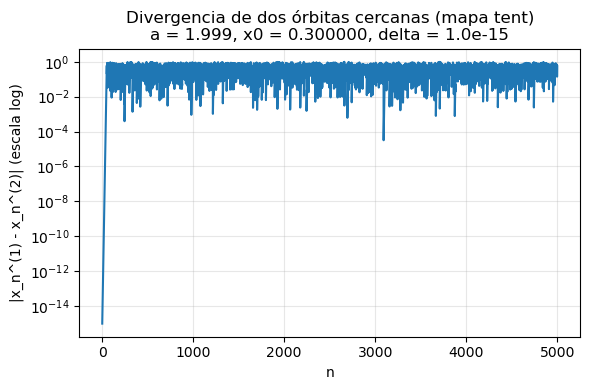

In [25]:
# 7.4 Divergencia de órbitas cercanas y efecto del redondeo (mapa tent)

a_caotico = 1.999
x0 = 0.3
delta0 = 1e-15

plot_divergence_two_orbits_tent(
    a=a_caotico,
    x0=x0,
    delta=delta0,    
    n_iters=5_000,
    log_scale=True,
)


La gráfica en escala semilogarítmica muestra:

- Una fase inicial donde la distancia entre las órbitas crece aproximadamente de forma exponencial, reflejando un exponente de Lyapunov positivo.
- Una posterior saturación cuando las órbitas se han separado tanto como permite el intervalo acotado $(0,1)$.

Este comportamiento resume el efecto combinado de:

- La **sensibilidad a las condiciones iniciales**, inherente a la dinámica caótica del mapa *tent*.
- Los **errores de redondeo** introducidos por la aritmética en coma flotante.

Ambos fenómenos son relevantes para entender las propiedades estadísticas de los bits generados a partir del sistema.


## 8. Conclusiones del análisis del mapa *tent*

A partir de este análisis se pueden extraer varias conclusiones:

- Para parámetros en la región caótica (por ejemplo $a \approx 2$), el mapa *tent* presenta una dinámica fuertemente caótica, con exponentes de Lyapunov positivos y órbitas que exploran densamente el intervalo $(0,1)$.
- El diagrama de bifurcación y la curva $\lambda(a)$ permiten identificar claramente las regiones de comportamiento periódico y caótico.
- El estudio del transitorio muestra que es razonable descartar varios miles de iteraciones antes de utilizar los valores de la órbita en el generador de bits.
- El análisis del umbral de binarización confirma que, para $a = 2$, la distribución de $x_n$ es aproximadamente uniforme, de modo que la probabilidad de obtener un uno se aproxima bien a $p(1) \approx 1 - \theta$.
- Desde el punto de vista numérico, la aritmética en doble precisión limita el espacio de estados pero sigue proporcionando un **espacio de claves muy amplio** cuando se usan como parte de la clave tanto el parámetro $a$ como la condición inicial $x_0$.
- La sensibilidad a las condiciones iniciales y a los parámetros, junto con la gran longitud de los ciclos numéricos, hacen del mapa *tent* un buen candidato como núcleo caótico para la generación de bitstreams pseudoaleatorios dentro del TFG.

Estas conclusiones complementan las obtenidas para los mapas logístico y de Hénon y ayudan a justificar el uso del mapa *tent* en el diseño del generador de bits del proyecto.


## Apéndice A – Sensibilidad del mapa tent al parámetro $a$

En este apéndice estudiamos cómo afecta una pequeña variación del parámetro $a$ a la órbita del mapa tent.

Partimos de la misma condición inicial $x_0$ y consideramos dos sistemas:

- Sistema 1: parámetro $a$.
- Sistema 2: parámetro $a + \Delta a$, con $\Delta a$ muy pequeño.

Denotaremos por $x_n(a)$ y $x_n(a + \Delta a)$ las órbitas correspondientes. Para cada instante $n$ medimos la diferencia

$$
d_n = \lvert x_n(a) - x_n(a + \Delta a) \rvert.
$$

Si el mapa es sensible al parámetro, incluso una variación muy pequeña $\Delta a$ provocará que $d_n$ crezca rápidamente con $n$, hasta saturarse por las limitaciones numéricas y por el hecho de que el sistema está confinado en el intervalo $(0,1)$.

En la figura siguiente representamos $d_n$ en escala semilogarítmica para un valor caótico de $a$ cercano a $2$, manteniendo la misma condición inicial $x_0$.


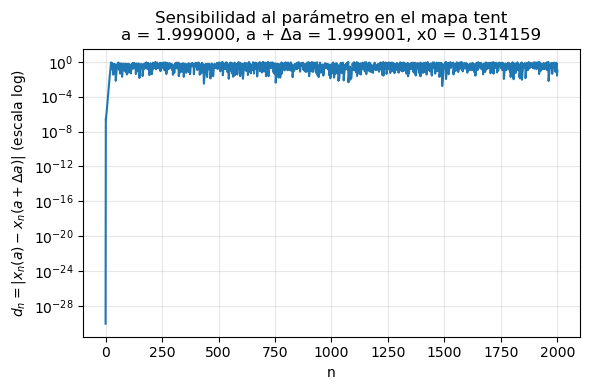

In [26]:
# Apéndice A: sensibilidad al parámetro a en el mapa tent
plot_param_sensitivity_tent(
    a=1.999,
    delta_a=1e-6,
    x0=0.314159,
    n_iters=2_000,
    log_scale=True,
)


### Interpretación del experimento de sensibilidad al parámetro

En la gráfica anterior se observa que:

- Para los primeros valores de $n$, la diferencia $d_n$ es extremadamente pequeña, del orden de la perturbación inicial en el parámetro $\Delta a$.
- A medida que avanza $n$, la diferencia crece de forma rápida (aproximadamente exponencial) y alcanza valores del orden de la amplitud típica de la órbita.
- Finalmente, $d_n$ se satura debido a que las dos órbitas están confinadas en el intervalo $(0,1)$ y a las limitaciones de la aritmética en coma flotante.

Este experimento ilustra que, en régimen caótico, el mapa tent no solo es sensible a las condiciones iniciales, sino también a pequeñas variaciones del parámetro $a$, algo relevante desde el punto de vista criptográfico cuando $a$ forma parte de la clave.


## Apéndice B – Comportamiento especial del caso $a = 2$ en el mapa tent

El mapa tent que hemos estudiado viene dado por

$$
x_{n+1} =
\begin{cases}
a\,x_n, & 0 \leq x_n < \tfrac{1}{2}, \\
a\,(1 - x_n), & \tfrac{1}{2} \leq x_n \leq 1.
\end{cases}
$$

Cuando $a = 2$, el mapa es topológicamente conjugado al *Bernoulli shift* (desplazamiento del desarrollo binario). De forma ideal (con aritmética exacta):

- si $x_0$ tiene un desarrollo binario infinito, la órbita explora el intervalo $(0,1)$ de manera caótica;
- si $x_0$ es una fracción diádica (de la forma $k / 2^m$), tras un número finito de iteraciones la órbita cae exactamente a $0$.

En aritmética de doble precisión, **todos** los números representables en $(0,1)$ son fracciones diádicas, por lo que en el caso $a = 2$ cualquier órbita acaba cayendo exactamente en $0$ tras un número finito de pasos y permanece allí para siempre.

En la práctica esto provoca:

- un transitorio caótico de longitud moderada;
- seguido de una fase estacionaria trivial $x_n = 0$ para todo $n$ grande.

El siguiente experimento lo ilustra para un valor típico de $x_0$.


Mapa tent con a = 2.0
Condición inicial x0 = 0.2
Primer índice n en el que x_n == 0.0 : 55


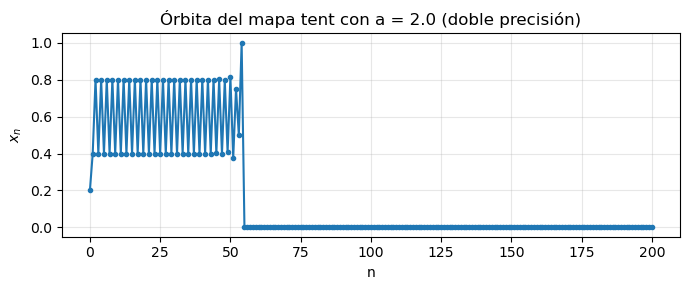

In [27]:
# Apéndice B: comportamiento especial del caso a = 2.0
plot_orbit_a_equals_2_tent(
    x0=0.2,
    n_iters=200,
)


### Interpretación del caso $a = 2$

En la salida numérica se observa que:

- Durante un cierto número de iteraciones la órbita se comporta de forma aparentemente caótica.
- A partir de un índice $n$ (por ejemplo, el valor indicado en `hit_zero_at`) aparece exactamente $x_n = 0$.
- A partir de ese instante, la órbita queda atrapada en el punto fijo $0$: se cumple $x_{n+1} = 2 \cdot 0 = 0$.

Esto confirma que, en aritmética de doble precisión, el caso $a = 2$ es **problemático para aplicaciones criptográficas**:

- el espacio de estados efectivo se colapsa a un ciclo de periodo $1$;
- la longitud del transitorio que precede a este colapso depende de $x_0$, pero siempre es finita.

Por este motivo, en el resto del proyecto se evita el uso de $a = 2$ y se trabaja en valores cercanos (por ejemplo $a = 1.999$), donde el comportamiento caótico es más robusto frente a las limitaciones numéricas.
